# Particle Filter Testing

Tests across three state-space models:
1. `SimpleLinearGaussianSSM` — single filter run, MC RMSE distribution, noise sensitivity, resampling method comparison
2. `LinearTSSM` — correct vs misspecified (Gaussian) filter on t-distributed data
3. `LinearARMASSM` — filter on ARMA(1,3) latent process

In [11]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from models.linear_gaussian import SimpleLinearGaussianSSM
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM
from estimation.particle_filter import ParticleFilter
from estimation.resampling_methods import (
    SystematicResampling, MultinomialResampling, ResidualResampling, StratifiedResampling
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── helpers ──────────────────────────────────────────────────────────────────

def filtered_trajectory(pf, state_idx=0):
    """Posterior mean of state component `state_idx` at each time step."""
    out = []
    for particles, weights in zip(pf.particle_history, pf.weight_history):
        w = weights.flatten()
        vals = particles if particles.ndim == 1 else particles[:, state_idx]
        out.append(np.average(vals, weights=w))
    return np.array(out)

def ess_trajectory(pf):
    return np.array([1.0 / np.sum(w.flatten() ** 2) for w in pf.weight_history])

def rmse(true, est):
    return np.sqrt(np.mean((np.asarray(true) - np.asarray(est)) ** 2))

---
## 1. SimpleLinearGaussianSSM — single run

In [3]:
model = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=42)
print(model)

T = 200
states, observations, true_loglik = model.generate_data(T)
# states/observations: (T, 1) — flatten for PF
obs_1d = observations[:, 0]
true_x  = states[:, 0]

pf = ParticleFilter(
    model=model, N_particles=2000, data=obs_1d,
    resample_method=SystematicResampling(seed=0)
)
_, ph, wh, rsh, loglik = pf.run_filter()

x_hat = filtered_trajectory(pf)
print(f"True log-lik : {float(np.squeeze(true_loglik)):.2f}")
print(f"PF  log-lik  : {loglik:.2f}")
print(f"RMSE         : {rmse(true_x, x_hat):.4f}")
print(f"Resample steps: {sum(rsh)} / {T}")

SimpleLinearGaussianSSM
        Simple linear Gaussian state-space model with 1D latent state and observation.
        Parameters: {'phi': 0.9, 'alpha': 1.0, 'sigma': 0.5, 'tau': 1.0}
        Transition: x_t = phi * x_(t-1) + eps_t,   eps_t ~ N(0, sigma^2)
        Observation: y_t = alpha * x_t + nu_t,       nu_t  ~ N(0, tau^2)
        
True log-lik : -267.41
PF  log-lik  : -335.33
RMSE         : 0.5869
Resample steps: 27 / 200


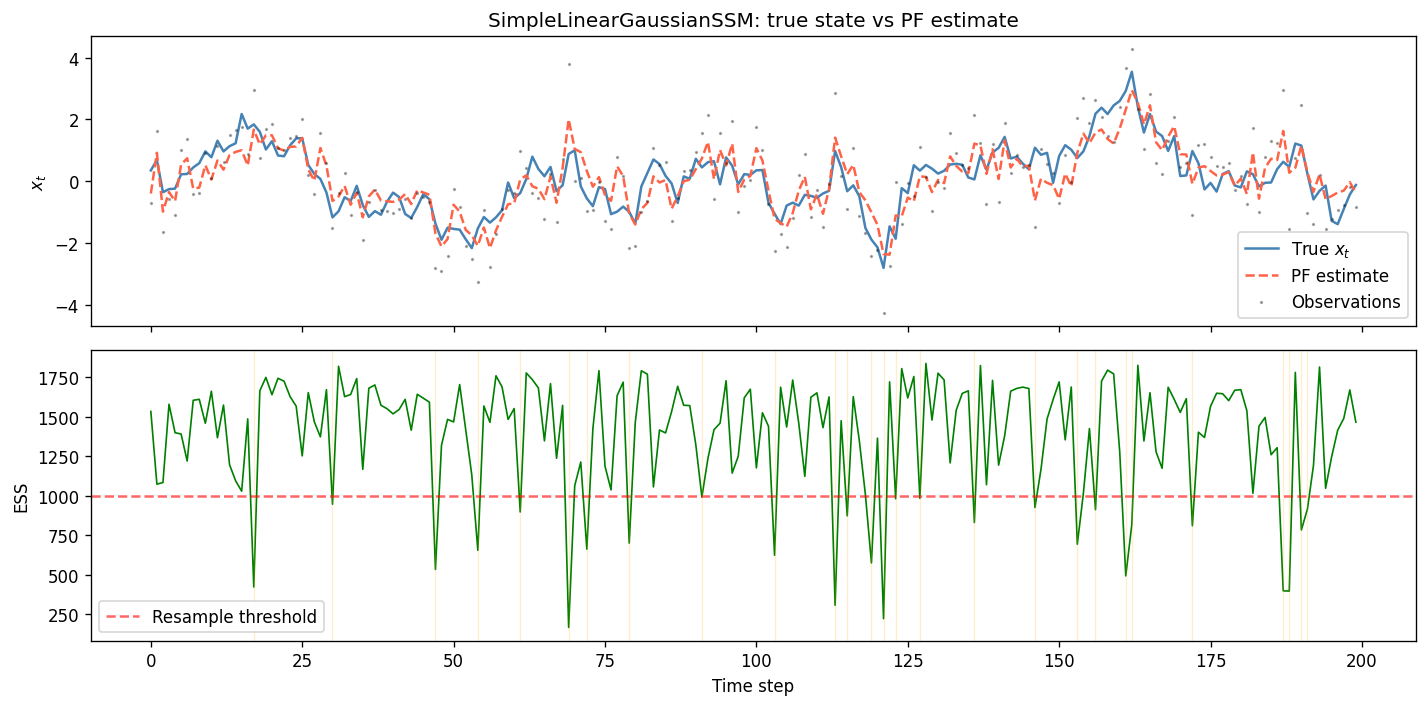

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(true_x, label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat,  label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].plot(obs_1d, '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('SimpleLinearGaussianSSM: true state vs PF estimate')

ess = ess_trajectory(pf)
axes[1].plot(ess, color='green', lw=1)
axes[1].axhline(pf.resample_threshold * pf.N_particles, color='red',
                linestyle='--', alpha=0.6, label='Resample threshold')
for s in [i for i, r in enumerate(rsh) if r]:
    axes[1].axvline(s, color='orange', alpha=0.2, lw=0.8)
axes[1].set_ylabel('ESS')
axes[1].set_xlabel('Time step')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 2. MC RMSE and log-likelihood distribution (50 trials)

In [5]:
N_trials = 50
T_mc = 150
N_mc  = 1000

rmse_mc   = []
loglik_mc = []

for seed in range(N_trials):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=seed)
    s, o, _ = m.generate_data(T_mc)
    pf_ = ParticleFilter(model=m, N_particles=N_mc, data=o[:, 0],
                         resample_method=SystematicResampling(seed=seed + 1000))
    _, ph_, wh_, _, ll = pf_.run_filter()
    x_hat_ = filtered_trajectory(pf_)
    rmse_mc.append(rmse(s[:, 0], x_hat_))
    loglik_mc.append(ll)

print(f"RMSE   : {np.mean(rmse_mc):.4f} ± {np.std(rmse_mc):.4f}")
print(f"Log-lik: {np.mean(loglik_mc):.2f} ± {np.std(loglik_mc):.2f}")

RMSE   : 0.6448 ± 0.0527
Log-lik: -252.42 ± 6.26


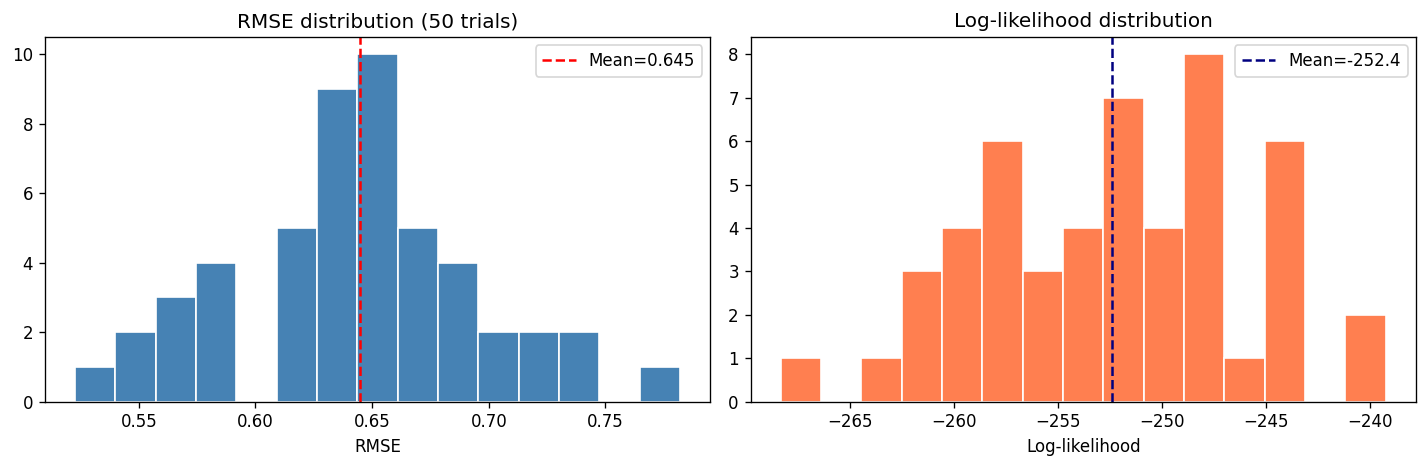

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rmse_mc, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(rmse_mc), color='red', linestyle='--', label=f'Mean={np.mean(rmse_mc):.3f}')
axes[0].set_xlabel('RMSE')
axes[0].set_title(f'RMSE distribution ({N_trials} trials)')
axes[0].legend()

axes[1].hist(loglik_mc, bins=15, color='coral', edgecolor='white')
axes[1].axvline(np.mean(loglik_mc), color='navy', linestyle='--', label=f'Mean={np.mean(loglik_mc):.1f}')
axes[1].set_xlabel('Log-likelihood')
axes[1].set_title('Log-likelihood distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Noise sensitivity: effect of σ and τ on filtering accuracy

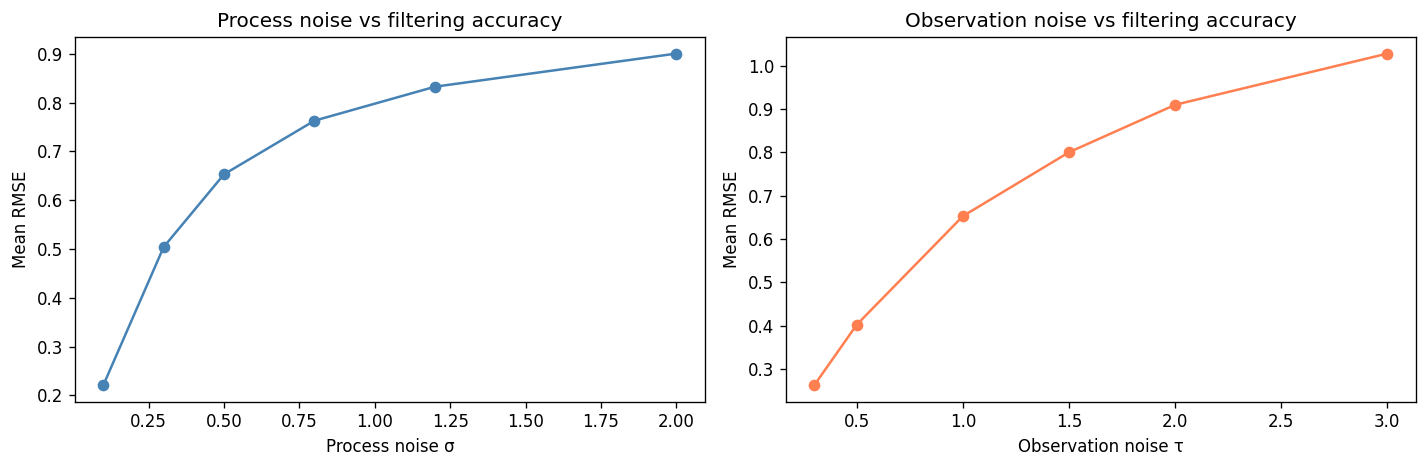

In [7]:
def mean_rmse(phi, alpha, sigma, tau, n_trials=15, T=100, N=500):
    errors = []
    for seed in range(n_trials):
        m = SimpleLinearGaussianSSM(phi=phi, alpha=alpha, sigma=sigma, tau=tau, seed=seed)
        s, o, _ = m.generate_data(T)
        pf_ = ParticleFilter(model=m, N_particles=N, data=o[:, 0],
                             resample_method=SystematicResampling(seed=seed + 500))
        pf_.run_filter()
        errors.append(rmse(s[:, 0], filtered_trajectory(pf_)))
    return np.mean(errors)

sigma_vals = [0.1, 0.3, 0.5, 0.8, 1.2, 2.0]
tau_vals   = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0]

sigma_rmse = [mean_rmse(0.9, 1.0, s, 1.0) for s in sigma_vals]
tau_rmse   = [mean_rmse(0.9, 1.0, 0.5, t) for t in tau_vals]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sigma_vals, sigma_rmse, 'o-', color='steelblue')
axes[0].set_xlabel('Process noise σ')
axes[0].set_ylabel('Mean RMSE')
axes[0].set_title('Process noise vs filtering accuracy')

axes[1].plot(tau_vals, tau_rmse, 'o-', color='coral')
axes[1].set_xlabel('Observation noise τ')
axes[1].set_ylabel('Mean RMSE')
axes[1].set_title('Observation noise vs filtering accuracy')

plt.tight_layout()
plt.show()

---
## 4. Resampling method comparison

In [8]:
resamplers = {
    'Systematic' : SystematicResampling,
    'Stratified' : StratifiedResampling,
    'Residual'   : ResidualResampling,
    'Multinomial': MultinomialResampling,
}

N_rs   = 30
T_rs   = 100
N_part = 500

rmse_rs   = {k: [] for k in resamplers}
loglik_rs = {k: [] for k in resamplers}

for seed in range(N_rs):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=seed)
    s, o, _ = m.generate_data(T_rs)
    for name, cls in resamplers.items():
        pf_ = ParticleFilter(model=m, N_particles=N_part, data=o[:, 0],
                             resample_method=cls(seed=seed + 2000), seed=seed + 3000)
        _, ph_, wh_, _, ll = pf_.run_filter()
        rmse_rs[name].append(rmse(s[:, 0], filtered_trajectory(pf_)))
        loglik_rs[name].append(ll)

print(f"{'Method':<12}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}")
print('-' * 50)
for name in resamplers:
    print(f"{name:<12}  {np.mean(rmse_rs[name]):>10.4f}  {np.std(rmse_rs[name]):>9.4f}  "
          f"{np.mean(loglik_rs[name]):>12.2f}")

Method         RMSE mean   RMSE std   loglik mean
--------------------------------------------------
Systematic        0.6423     0.0693       -168.95
Stratified        0.6444     0.0679       -169.19
Residual          0.6450     0.0707       -169.16
Multinomial       0.6464     0.0709       -169.07


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_35784/3169042032.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_35784/3169042032.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([loglik_rs[n] for n in names], labels=names)


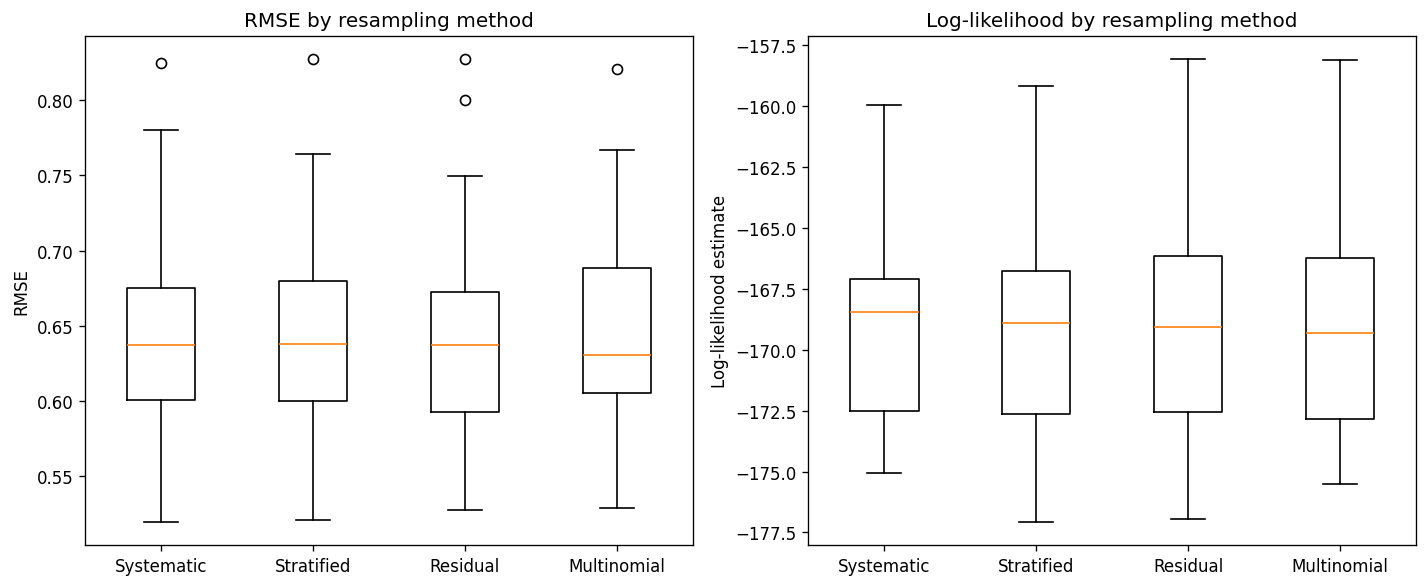

In [9]:
names = list(resamplers.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by resampling method')

axes[1].boxplot([loglik_rs[n] for n in names], labels=names)
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood by resampling method')

plt.tight_layout()
plt.show()

---
## 5. LinearTSSM — correct vs misspecified filter

Data generated from a model with t-distributed process noise (df=5).  
Compare PF using the correct `LinearTSSM` against a misspecified `SimpleLinearGaussianSSM` filter.

In [13]:
model_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=42)
print(model_t)

T_t = 200
states_t, obs_t, _ = model_t.generate_data(T_t)
obs_t_1d = obs_t[:, 0]
true_x_t = states_t[:, 0]

# correct model
pf_t_correct = ParticleFilter(
    model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_correct = pf_t_correct.run_filter()
x_correct = filtered_trajectory(pf_t_correct)

# misspecified Gaussian filter
pf_t_misspec = ParticleFilter(
    model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_misspec = pf_t_misspec.run_filter()
x_misspec = filtered_trajectory(pf_t_misspec)

print(f"t-SSM  (correct)     loglik={ll_correct:.2f}  RMSE={rmse(true_x_t, x_correct):.4f}")
print(f"Gauss  (misspecified) loglik={ll_misspec:.2f}  RMSE={rmse(true_x_t, x_misspec):.4f}")

LinearTSSM
        Linear T state-space model with 1D latent state and observation.
        Parameters: {'alpha': 1.0, 'tau': 1.0, 'phi': 0.9, 'sigma': 0.5, 'df': 5}
        Transition: x_t = phi * x_(t-1) + sigma * eps_t,   eps_t ~ t(df, 1)
        Observation: y_t = alpha * x_t + tau * nu_t,       nu_t  ~ N(0, 1)
        
t-SSM  (correct)     loglik=-343.78  RMSE=0.6721
Gauss  (misspecified) loglik=-335.54  RMSE=0.6595


t-SSM   RMSE: 0.7476 ± 0.0761
Gauss   RMSE: 0.7422 ± 0.1521


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_35784/1558544977.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([rmse_correct_t, rmse_misspec_t],


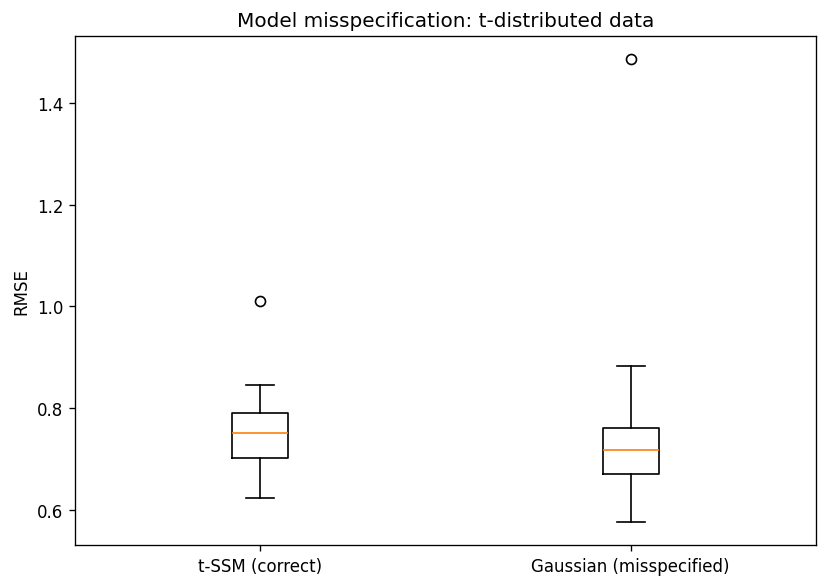

In [14]:
N_t = 30
T_t_mc = 100
N_t_part = 1000

rmse_correct_t  = []
rmse_misspec_t  = []

for seed in range(N_t):
    m_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed)
    s_t, o_t, _ = m_t.generate_data(T_t_mc)
    obs_flat = o_t[:, 0]

    pf_c = ParticleFilter(
        model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 200)
    )
    pf_c.run_filter()
    rmse_correct_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_c)))

    pf_m = ParticleFilter(
        model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 300)
    )
    pf_m.run_filter()
    rmse_misspec_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_m)))

print(f"t-SSM   RMSE: {np.mean(rmse_correct_t):.4f} ± {np.std(rmse_correct_t):.4f}")
print(f"Gauss   RMSE: {np.mean(rmse_misspec_t):.4f} ± {np.std(rmse_misspec_t):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([rmse_correct_t, rmse_misspec_t],
           labels=['t-SSM (correct)', 'Gaussian (misspecified)'])
ax.set_ylabel('RMSE')
ax.set_title('Model misspecification: t-distributed data')
plt.tight_layout()
plt.show()

---
## 6. LinearARMASSM

Latent process: $x_t = c + \phi x_{t-1} + \nu_t + \theta_1 \nu_{t-1} + \theta_2 \nu_{t-2} + \theta_3 \nu_{t-3}$.  
Markov state: $s_t = [x_t,\, \nu_{t-1},\, \nu_{t-2}, \, \nu_{t-3}]^\top$. PF estimates the full 4D state; we compare on the $x_t$ component.

In [15]:
model_arma = LinearARMASSM(
    phi=0.8, alpha=1.0, c=0.0,
    theta_1=0.3, theta_2=0.2, theta_3=0.1,
    sigma=0.5, tau=1.0, seed=42
)
print(model_arma)

T_arma = 200
states_arma, obs_arma, _ = model_arma.generate_data(T_arma)
obs_arma_1d = obs_arma[:, 0]
true_x_arma = states_arma[:, 0]

pf_arma = ParticleFilter(
    model=model_arma, N_particles=3000, data=obs_arma_1d,
    resample_method=SystematicResampling(seed=5)
)
_, ph_arma, wh_arma, rsh_arma, loglik_arma = pf_arma.run_filter()

x_hat_arma = filtered_trajectory(pf_arma, state_idx=0)

print(f"ARMA PF log-likelihood: {loglik_arma:.2f}")
print(f"RMSE (x_t component)  : {rmse(true_x_arma, x_hat_arma):.4f}")
print(f"Resample steps        : {sum(rsh_arma)} / {T_arma}")

LinearARMASSM
        Latent state dimension: 4
        Observation dimension: 1
        Parameters: {'phi': 0.8, 'alpha': 1.0, 'c': 0.0, 'theta_1': 0.3, 'theta_2': 0.2, 'theta_3': 0.1, 'sigma': 0.5, 'tau': 1.0}
        Transition: transition equation here
        Observation: observation equation here
        
ARMA PF log-likelihood: -345.31
RMSE (x_t component)  : 0.6467
Resample steps        : 35 / 200


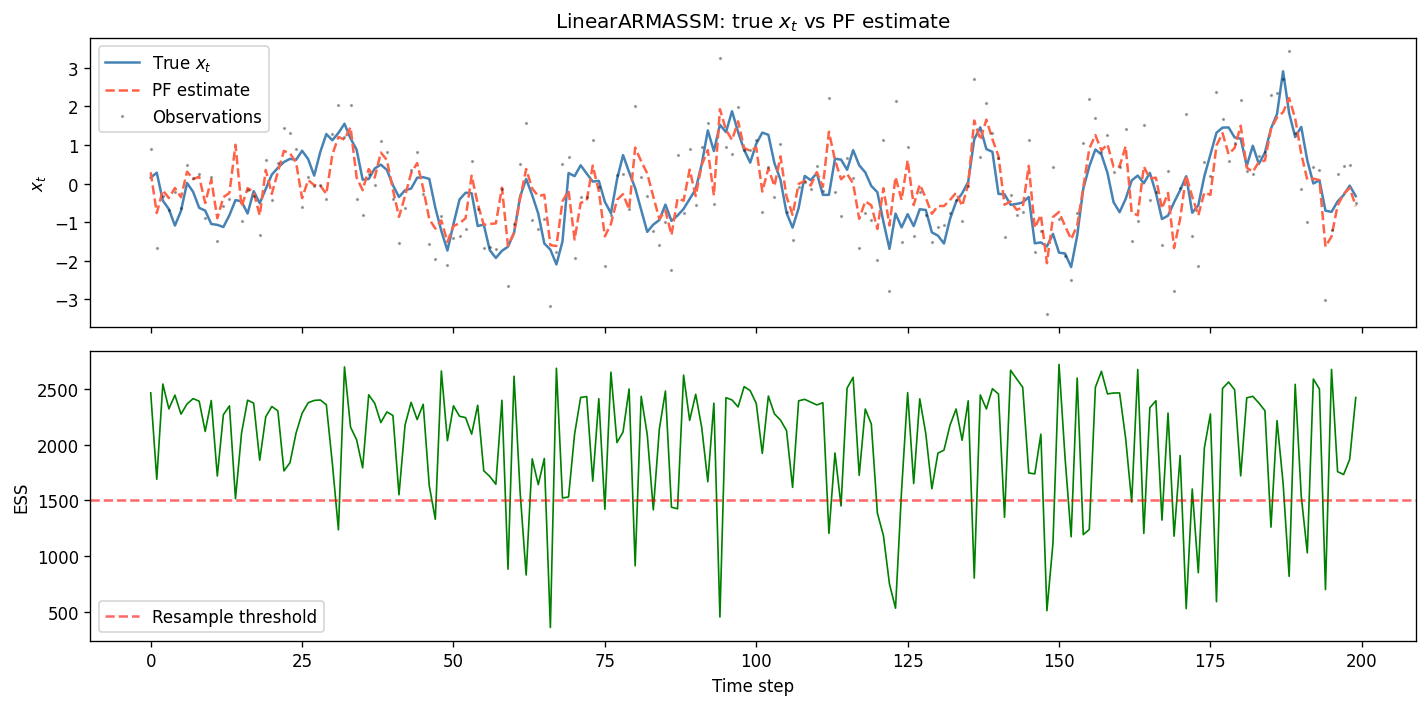

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(true_x_arma,  label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat_arma,   label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].plot(obs_arma_1d,  '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('LinearARMASSM: true $x_t$ vs PF estimate')

ess_arma = ess_trajectory(pf_arma)
axes[1].plot(ess_arma, color='green', lw=1)
axes[1].axhline(pf_arma.resample_threshold * pf_arma.N_particles,
                color='red', linestyle='--', alpha=0.6, label='Resample threshold')
axes[1].set_ylabel('ESS')
axes[1].set_xlabel('Time step')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Next steps

- **Kalman filter MLE**: for `SimpleLinearGaussianSSM`, the marginal log-likelihood is analytically tractable via the Kalman filter. Implement `kalman_log_likelihood(params, observations)` and optimize with `scipy.optimize.minimize`.
- **PMMH**: use the PF log-likelihood estimate as an unbiased estimator inside a Metropolis–Hastings loop to do Bayesian inference over `(phi, sigma, tau)`. The PF is already returning `loglik`.
- **RBPF / Kim filter**: for the regime-switching model in `src/models/regime_switching.py`, the Rao-Blackwellized PF marginalizes out the continuous state analytically while sampling discrete regimes.